# Easy-Money 🎢
### Volatility ETPs bleed lower every day — so can you just short them and collect free money?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free money?: Busted](https://img.shields.io/badge/Free_money%3F-Busted-8b949e?style=flat-square)

VIX futures are almost always in *contango*, so a long-volatility ETP like **VIXY** loses value nearly every single day — a dollar at its 2011 launch is worth a fraction of a *cent* today. The folklore says: short it, pocket the bleed, near-free money. We take the trade literally and ask the two questions that matter: is the carry **real** (yes, and it's huge), and is it **free** (no — you're selling crash insurance, and the bill comes due).

> 📓 **This is the plain-language layer.** The statistics, the tail maths and the sizing are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Educational, reproducible research — every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (easy_money/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from easy_money import data, strategy

AS_OF = "2026-06-12"
vixy = data.load_real("VIXY", mode="total_return").loc[:AS_OF]
vix  = data.load_real("^VIX", start="1990-01-01", mode="total_return").loc[:AS_OF]
close = vixy["close"]
decay = strategy.decay_stats(close)
carry = strategy.short_vol_backtest(close, leverage=1.0, cost_bps=5.0, borrow_bps_annual=300.0)
sized = strategy.sized_to_survive(close, max_loss_on_worst_day=0.25, cost_bps=5.0, borrow_bps_annual=300.0)
hac_t = strategy.hac_tstat(carry["net"].to_numpy())
print(f"VIXY total return: {len(close):,} rows  {close.index[0].date()} -> {close.index[-1].date()}  fingerprint={data.fingerprint(vixy)}")
print(f"VIXY decay  CAGR {decay['cagr']*100:.2f}%/yr  -> {decay['final_frac_of_start']*100:.4f}% of start")
print(f"short-vol   Sharpe {carry['sharpe']:.3f}  HAC t {hac_t:+.2f}  maxDD {carry['max_dd']*100:.1f}%  skew {carry['skew']:+.2f}  exkurt {carry['excess_kurt']:+.1f}")


VIXY total return: 3,883 rows  2011-01-04 -> 2026-06-12  fingerprint=929eac2a9e69
VIXY decay  CAGR -48.46%/yr  -> 0.0037% of start
short-vol   Sharpe 0.568  HAC t +2.31  maxDD -92.3%  skew -1.66  exkurt +9.4


C:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\92-easy-money\easy_money\data.py:123: UserWarning: VIXY: 1 daily move(s) beyond ±40% [2024-08-05] — almost certainly a data/adjustment artefact, not a market move. Inspect before publishing anything built on this series.
  raw = qdata.fetch(ticker, start=start, end=end, mode=mode, use_cache=use_cache)
C:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\92-easy-money\easy_money\data.py:123: UserWarning: ^VIX: 6 daily move(s) beyond ±40% [1991-11-15, 1990-07-23, 2016-06-24, 1997-10-28, 2021-11-26 (+1 more)] — almost certainly a data/adjustment artefact, not a market move. Inspect before publishing anything built on this series.
  raw = qdata.fetch(ticker, start=start, end=end, mode=mode, use_cache=use_cache)


## The answer first 🎯

| Question | Answer |
|---|---|
| Does the long-vol ETP really bleed? | **Yes** — VIXY's CAGR is **-48.46%/yr**; a dollar at launch is worth about **0.0037%** of itself today. |
| Does shorting it make money? | **Yes** — about **+14.79%/yr**, Sharpe **0.57**. The carry is real. |
| Is it *free* money? | **No** — worst day **-43.1%**, max drawdown **-92.3%**. You're being paid to insure other people against crashes. |

## 1 · The claim

*"VIX futures are almost always in contango, so a long-vol ETP like VIXY bleeds lower every day. Just short it (or hold an inverse like SVXY) and harvest the roll — it's near-free money, an almost risk-less carry."* It's one of the most-repeated trades in retail volatility forums.

## 2 · So what?

If a security reliably loses ~48% a year, shorting it sounds like the closest thing to a money printer in markets. If that were *risk-less*, it would be the best trade in the world. The stakes are exactly that big — so it deserves an honest test of the **downside**, not a cherry-picked equity curve from a calm year.

## 3 · How would we even know?

We short VIXY (total-return adjusted, so its reverse splits fold into one smooth NAV), pay **5 bps** to trade and **300 bps/yr** to borrow the shares, and act one day after sizing. Then we don't just look at the average — we look at the **worst day**, the **drawdown**, and the **shape of the losses**. If the gains are steady but the losses are rare and gigantic, it's not free money — it's an insurance premium.

## 4 · The teardown — let's actually look

First: the decay itself. This is the carry.

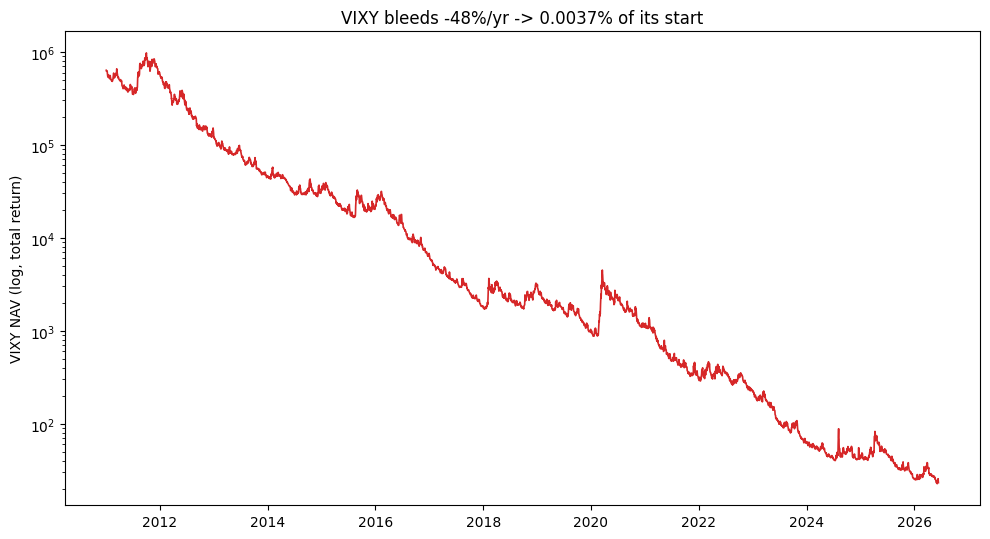

total return over the window: -100.0%


In [2]:
fig, ax = plt.subplots(figsize=(10,5.5))
ax.plot(close, lw=1.2, color='C3')
ax.set_yscale('log'); ax.set_ylabel('VIXY NAV (log, total return)')
ax.set_title(f"VIXY bleeds {decay['cagr']*100:.0f}%/yr -> {decay['final_frac_of_start']*100:.4f}% of its start")
plt.tight_layout(); plt.show()
print(f"total return over the window: {decay['total_return']*100:,.1f}%")

A near-vertical slide on a log scale — the contango bleed is **relentless and real**. Now flip it: short that decay and watch the carry equity curve. Look for the **cliffs**.

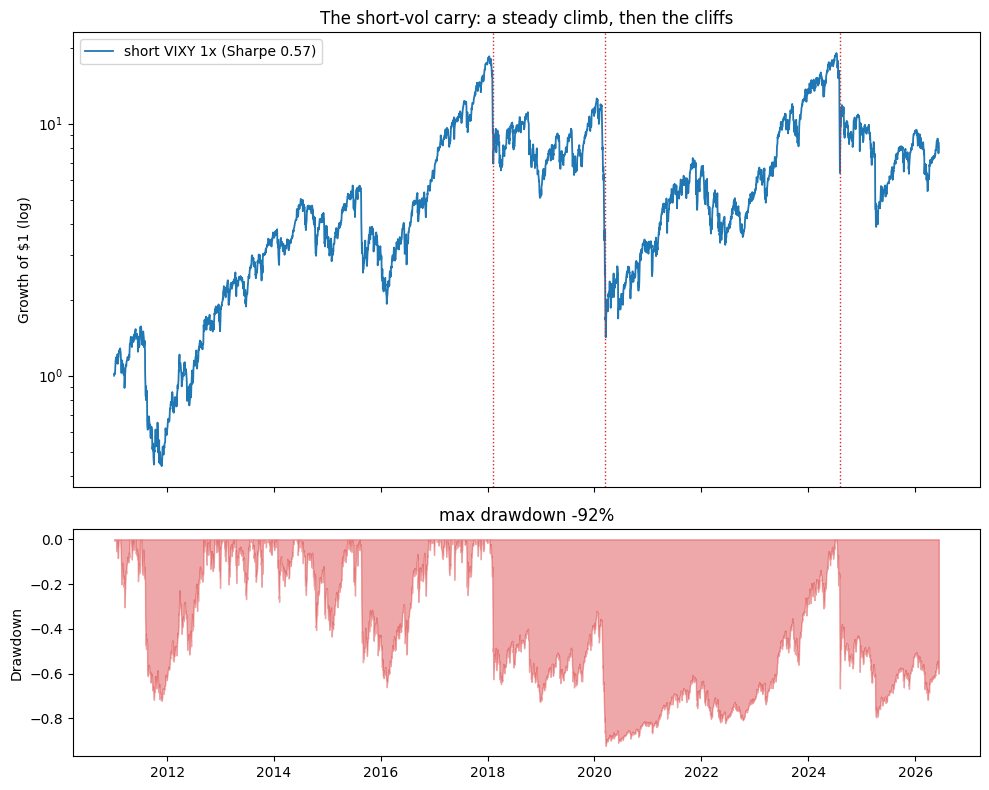

In [3]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,8), sharex=True, height_ratios=[2,1])
ax1.plot(carry['equity'], lw=1.3, color='C0', label=f"short VIXY 1x (Sharpe {carry['sharpe']:.2f})")
ax1.set_yscale('log'); ax1.set_ylabel('Growth of $1 (log)'); ax1.legend()
ax1.set_title('The short-vol carry: a steady climb, then the cliffs')
for d in ['2018-02-05','2020-03-16','2024-08-05']:
    ax1.axvline(pd.Timestamp(d), color='C3', ls=':', lw=1)
eq = carry['equity']; dd = eq/eq.cummax()-1
ax2.fill_between(dd.index, dd.values, 0, color='C3', alpha=.4)
ax2.set_ylabel('Drawdown'); ax2.set_title(f"max drawdown {dd.min()*100:.0f}%")
plt.tight_layout(); plt.show()

See the dotted lines — **Feb 2018** (Volmageddon), **Mar 2020** (COVID), **Aug 2024** (the yen carry-unwind). Each is a near-vertical drop that erases years of patient carry. The max drawdown is **-92.3%**: the strategy that looked like a money printer can lose almost everything in a single bad month.

Now the shape of the daily returns — the thing the average hides.

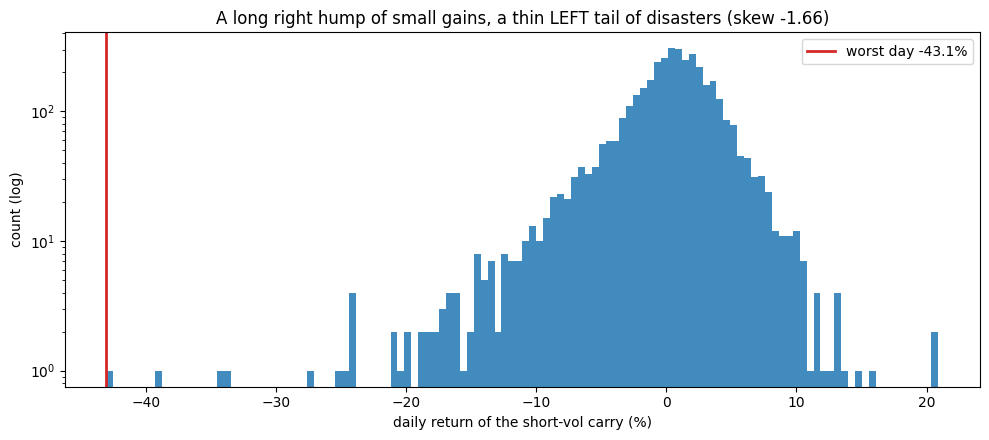

In [4]:
r = carry['net']*100
fig, ax = plt.subplots(figsize=(10,4.5))
ax.hist(r, bins=120, color='C0', alpha=.85)
ax.axvline(r.min(), color='C3', lw=2, label=f"worst day {r.min():.1f}%")
ax.set_yscale('log'); ax.set_xlabel('daily return of the short-vol carry (%)'); ax.set_ylabel('count (log)')
ax.set_title(f"A long right hump of small gains, a thin LEFT tail of disasters (skew {carry['skew']:.2f})"); ax.legend()
plt.tight_layout(); plt.show()

Almost every day is a small green gain — and then there's that lonely red bar at **-43.1%**. That asymmetry (skew **-1.66**, fat tails) *is* the trade: lots of small wins, rare catastrophic losses. That's what selling insurance looks like.

## 5 · The verdict

- **The carry is real → Signal REAL.** VIXY bleeds -48.46%/yr; shorting it earns +14.79%/yr at Sharpe 0.57, and the gain is statistically solid.
- **It is NOT free money → Busted.** Worst day -43.1%, drawdown -92.3%, a lop-sided payoff (skew -1.66). You're paid a steady drip to pay out in crashes.
- **Tradable? → Fragile.** Even sized so the worst day costs ≤25% of capital, it still draws down -72.0% — and one mis-sized spike took the **XIV** ETN to zero in 2018.

## 6 · Could you actually trade it?

You can short VIXY or hold an inverse — they're liquid. The problem isn't capacity, it's the tail. To survive a 2018/2020/2024 spike you must size **tiny** (here, about **0.581×** of capital), and at that size the carry is modest while the drawdown is *still* **-72.0%**. The inverse ETN XIV was sized for the good times and lost ~96% in a single afternoon on 5 Feb 2018 — and was wound down. *"Free money"* it is not.

## 7 · Going further 🚪

- Does a **VIX term-structure filter** (only short when the curve is steeply in contango) dodge some spikes? Or does it just sell the cheapest insurance right before it's needed?
- Does pairing the short with a small **long-vol tail hedge** (a deep-OTM call) keep the carry while capping the −43% day?
- Roll-yield on **other vol ETPs** (UVXY, the defunct XIV/SVXY) — same premium, same tail? Fork it.